# Gym Churn Analysis

## Data Columns
The dataset contains churn information for the current month and member data for the previous month.

- Churn - cancellation for the current month
- Gender - The user's gender
- Near_Location - If the user lives or works in the neighborhood where the gym is located.
- Partner - If the user works in an associated company (the gym has associated companies whose employees get discounts; in those cases, the gym stores information about the clients' employers).
- Promo_friends - If the user originally signed up through a "bring a friend" offer (they used a friend's promotional code when they paid the first subscription).
- Phone - If the user provided their phone number.
- Contract_period - The customer's contract period in months
- Group_visits - Whether the customer's membership allows to bring friends
- Age - The customer's age
- Avg_additional_charges_total
- Month_to_end_contract - Months until the contract ends
- Lifetime - the time (in months) since the user first arrived at the gym.
- Avg_class_frequency_total - Average number of classes the customer attended per week overall
- Avg_class_frequency_current_month - Average number of classes the customer attended per week in the current month

## TODO
- EDA
- Statistical tests on means of numerical variables for churn vs not churn populations
- Clustering to find valuable segments
- Statistical tests on clusters
- Churn predition with bootstrapping
- Extra data generation

- Descriptive churn vs not churn comparison
- Cluster within churners or non-churners separately to see what churner vs loyal segments look like
- Predictive model to quantify feature importance
- Survival analysis
- Cohort analysis: Look at groups that joined around the same time and see how their churn patterns evolve.

## Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from minieda import summarize, summarize_missing
from scipy.stats import ttest_ind

In [2]:
df = pd.read_csv("gym_churn_us.csv")

In [3]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


In [4]:
summarize(df)

,dtype,count,unique,unique_perc,missing,missing_perc,zero,zero_perc,mean,std,min,50%,max,skew
gender,int64,4000,2,0.05,0,0.0,1959,48.98,0.51,0.50,0.00,1.00,1.00,-0.04
Near_Location,int64,4000,2,0.05,0,0.0,619,15.48,0.85,0.36,0.00,1.00,1.00,-1.91
Partner,int64,4000,2,0.05,0,0.0,2053,51.32,0.49,0.50,0.00,0.00,1.00,0.05
Promo_friends,int64,4000,2,0.05,0,0.0,2766,69.15,0.31,0.46,0.00,0.00,1.00,0.83
Phone,int64,4000,2,0.05,0,0.0,386,9.65,0.90,0.30,0.00,1.00,1.00,-2.73
Contract_period,int64,4000,3,0.08,0,0.0,0,0.00,4.68,4.55,1.00,1.00,12.00,0.71
Group_visits,int64,4000,2,0.05,0,0.0,2351,58.78,0.41,0.49,0.00,0.00,1.00,0.36
Age,int64,4000,23,0.57,0,0.0,0,0.00,29.18,3.26,18.00,29.00,41.00,-0.06
Avg_additional_charges_total,float64,4000,4000,100.00,0,0.0,0,0.00,146.94,96.36,0.15,136.22,552.59,0.62
Month_to_end_contract,float64,4000,12,0.30,0,0.0,0,0.00,4.32,4.19,1.00,1.00,12.00,0.81


In [5]:
categorical_vars = ["gender", "Near_Location", "Partner",  "Promo_friends", "Phone", "Contract_period", "Group_visits"]

numerical_vars = ["Age", "Avg_additional_charges_total", "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total", "Avg_class_frequency_current_month"]

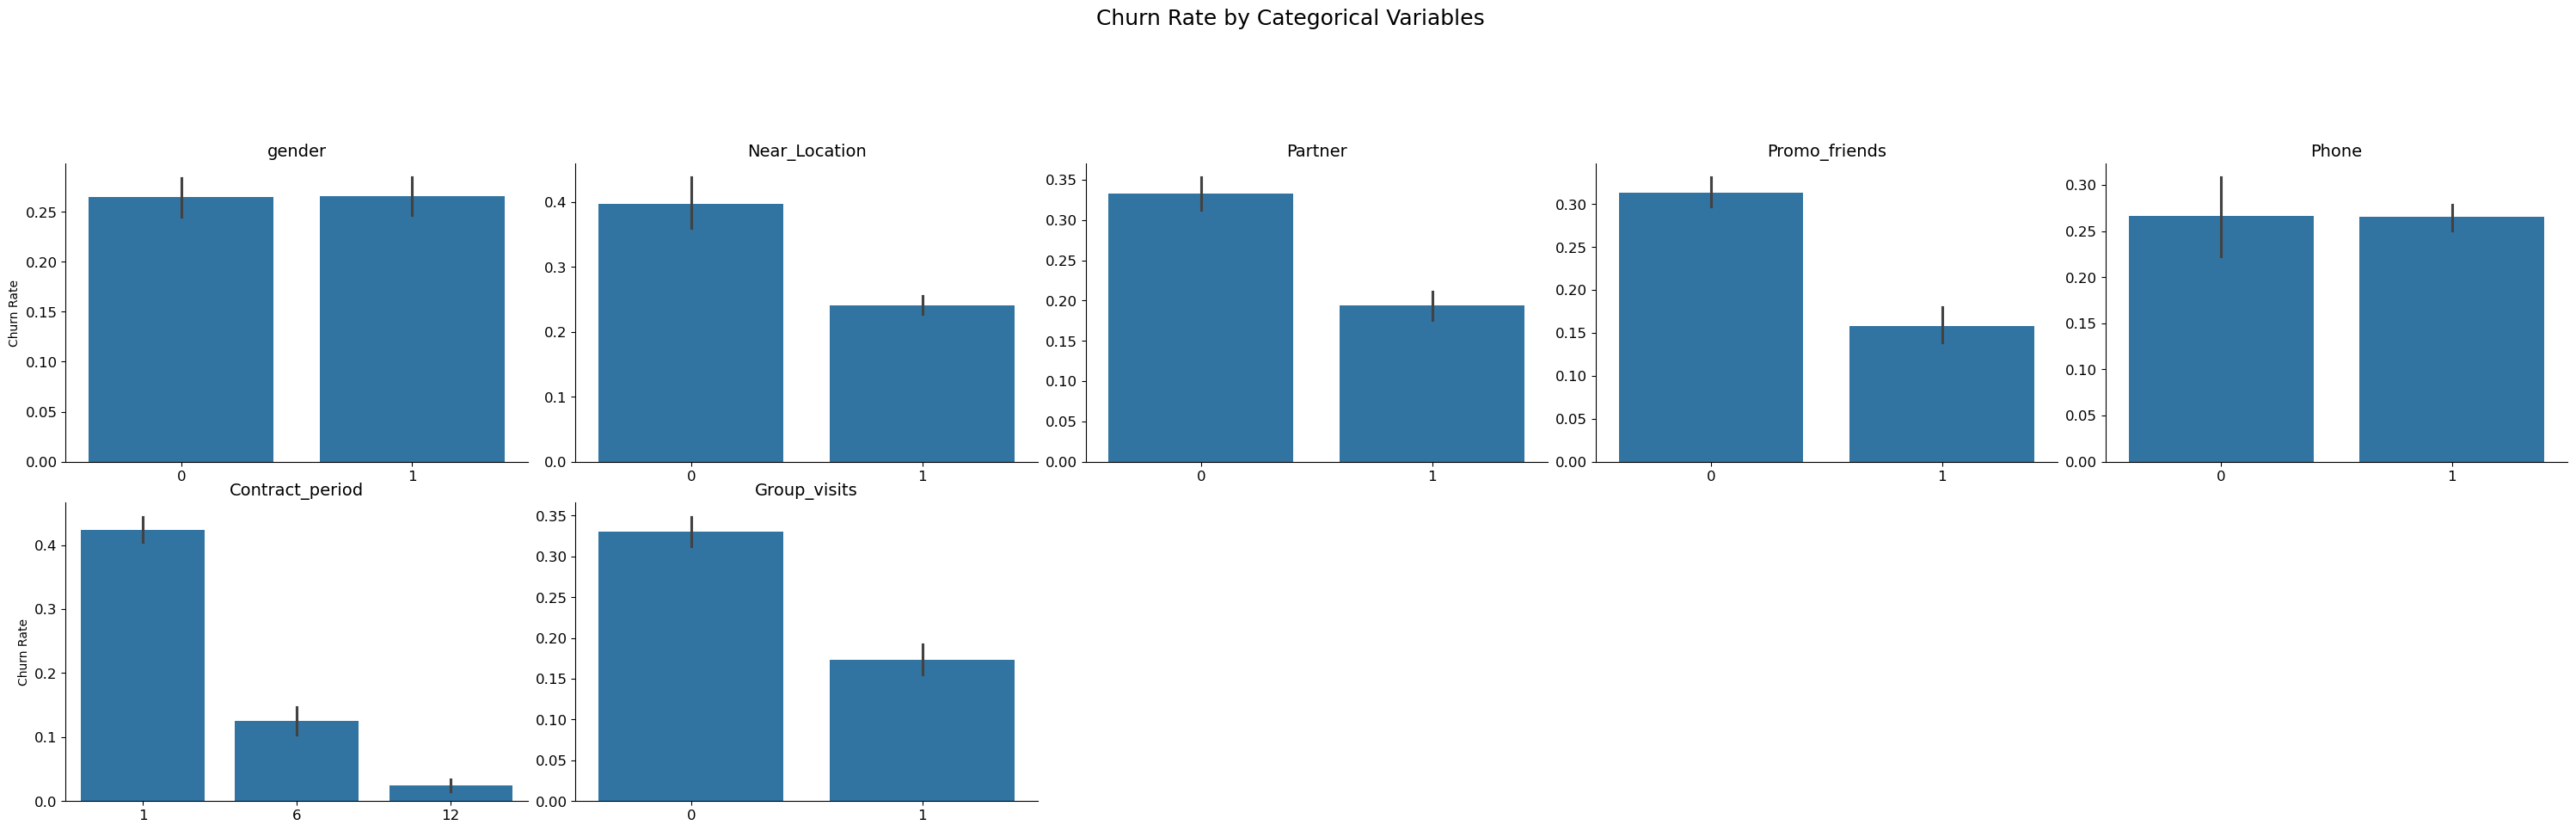

In [6]:
# Churn proportion for categorical variables

g = sns.FacetGrid(
    pd.melt(df, id_vars="Churn", value_vars=categorical_vars),
    col="variable",
    col_wrap=5,
    sharey=False,
    sharex=False,
    height=5,     # each subplot 4 inches tall
    aspect=1.2    # width = 1.2 × height
)
g.map_dataframe(sns.barplot, x="value", y="Churn", estimator=lambda x: sum(x)/len(x))
g.set_axis_labels("", "Churn Rate")
g.set_titles("{col_name}", size=14)
g.fig.suptitle("Churn Rate by Categorical Variables", fontsize=18)
g.fig.subplots_adjust(top=0.8)  # adjust to fit the title

for ax in g.axes.flat:
    ax.tick_params(labelsize=12)
plt.show()

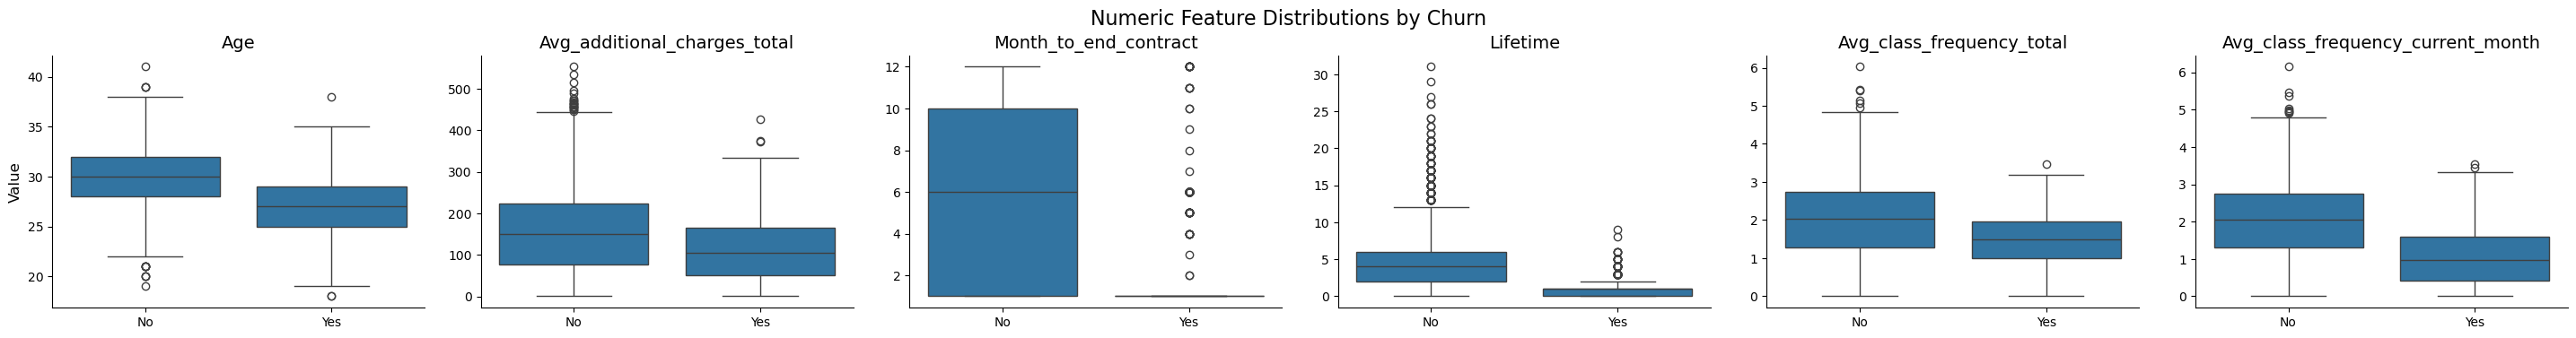

In [7]:
df_plot = df.copy()
df_plot["Churn_label"] = df_plot["Churn"].map({0: "No", 1: "Yes"})

# reshape to long format for FacetGrid
melted = pd.melt(df_plot, id_vars="Churn_label", value_vars=numerical_vars, var_name="variable", value_name="value")

# build the facet grid of boxplots
g = sns.FacetGrid(melted, col="variable", sharey=False, height=4, aspect=1.2)

g.map_dataframe(sns.boxplot, x="Churn_label", y="value", showfliers=True)

# cosmetics: titles, labels, fonts
g.set_titles("{col_name}", size=14)
g.set_axis_labels("", "Value", fontsize=12)

for ax in g.axes.flat:
    ax.tick_params(labelsize=10)

# global title + spacing
g.fig.suptitle("Numeric Feature Distributions by Churn", fontsize=16)
g.fig.subplots_adjust(top=0.85, wspace=0.15, hspace=0.25)

plt.show()

In [17]:
# T-test 
# def run_ttest(variable):
#     churners = df[df["Churn"] == 1][variable]
#     non_churners = df[df["Churn"] == 0][variable]
#     t_stat, p_val = ttest_ind(churners, non_churners, equal_var=False)
#     print(f"{variable:<35} t-stat: {t_stat:>6.3f}   p-value: {p_val:.3e}")

def run_ttests(df, numerical_vars):
    results = []
    for var in numerical_vars:
        churners = df[df["Churn"] == 1][var]
        non_churners = df[df["Churn"] == 0][var]
        t_stat, p_val = ttest_ind(churners, non_churners, equal_var=False)
        results.append({"Variable": var, "t-stat": t_stat, "p-value": p_val})
    return(pd.DataFrame(results))

ttest_results = run_ttests(df, numerical_vars)
print(ttest_results)


                            Variable     t-stat        p-value
0                                Age -28.501379  1.438415e-149
1       Avg_additional_charges_total -14.391491   4.230473e-45
2              Month_to_end_contract -35.996482  1.284839e-244
3                           Lifetime -46.989716   0.000000e+00
4          Avg_class_frequency_total -19.367540   2.011288e-78
5  Avg_class_frequency_current_month -32.553372  1.049332e-193


In [18]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, t

def run_ttests_with_means(df, numerical_vars, churn_col="Churn", pretty=False):
    """
    Compare numeric variables between churners (1) and non-churners (0).
    Uses Welch's t-test (unequal variances), and reports:
      - group means
      - mean difference (churners - non-churners)
      - t-statistic, p-value
      - 95% CI for the mean difference (Welch)
      - Hedges' g (effect size, small-sample corrected)

    Params
    ------
    df : DataFrame
    numerical_vars : list[str]
    churn_col : str (default "Churn")
    pretty : bool -> if True, returns a formatted table (strings)

    Returns
    -------
    DataFrame
    """
    rows = []

    for var in numerical_vars:
        g1 = df[df[churn_col] == 1][var].dropna()  # churners
        g0 = df[df[churn_col] == 0][var].dropna()  # non-churners

        n1, n0 = len(g1), len(g0)
        m1, m0 = g1.mean(), g0.mean()
        s1, s0 = g1.std(ddof=1), g0.std(ddof=1)

        # Welch t-test
        t_stat, p_val = ttest_ind(g1, g0, equal_var=False)

        # Mean difference and its SE (Welch)
        diff = m1 - m0
        se = np.sqrt((s1**2 / n1) + (s0**2 / n0))

        # Welch-Satterthwaite degrees of freedom
        df_welch_num = (s1**2 / n1 + s0**2 / n0) ** 2
        df_welch_den = ((s1**2 / n1) ** 2) / (n1 - 1) + ((s0**2 / n0) ** 2) / (n0 - 1)
        dof = df_welch_num / df_welch_den

        # 95% CI for mean difference
        t_crit = t.ppf(0.975, dof)
        ci_low = diff - t_crit * se
        ci_high = diff + t_crit * se

        # Effect size: Hedges' g (using pooled SD, then small-sample correction)
        # (common practice even with Welch test for a standardized difference)
        sp2 = ((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2)
        sp = np.sqrt(sp2)
        d = diff / sp if sp > 0 else np.nan
        J = 1 - (3 / (4*(n1 + n0) - 9))  # small sample correction
        g_hedges = d * J

        rows.append({
            "Variable": var,
            "n_churn": n1, "mean_churn": m1,
            "n_non": n0, "mean_non": m0,
            "diff_mean": diff,
            "t_stat": t_stat, "p_value": p_val,
            "ci_low": ci_low, "ci_high": ci_high,
            "hedges_g": g_hedges
        })

    out = pd.DataFrame(rows).sort_values("p_value")

    if not pretty:
        return out.reset_index(drop=True)

    # Pretty formatting for presentation
    out_fmt = out.copy()
    out_fmt["mean_churn"] = out_fmt["mean_churn"].map(lambda x: f"{x:.3f}")
    out_fmt["mean_non"]   = out_fmt["mean_non"].map(lambda x: f"{x:.3f}")
    out_fmt["diff_mean"]  = out_fmt["diff_mean"].map(lambda x: f"{x:+.3f}")
    out_fmt["t_stat"]     = out_fmt["t_stat"].map(lambda x: f"{x:.3f}")
    out_fmt["p_value"]    = out_fmt["p_value"].map(lambda x: f"{x:.3e}")
    out_fmt["ci"]         = out.apply(lambda r: f"[{r.ci_low:.3f}, {r.ci_high:.3f}]", axis=1)
    out_fmt["hedges_g"]   = out_fmt["hedges_g"].map(lambda x: f"{x:+.3f}")

    cols = ["Variable", "n_churn", "n_non", "mean_churn", "mean_non",
            "diff_mean", "t_stat", "p_value", "ci", "hedges_g"]
    return out_fmt[cols].reset_index(drop=True)

#Example:
results = run_ttests_with_means(df, numerical_vars, pretty=True)
results

,Variable,n_churn,n_non,mean_churn,mean_non,diff_mean,t_stat,p_value,ci,hedges_g
0,Lifetime,1061,2939,0.991,4.712,-3.721,-46.990,0.000e+00,"[-3.876, -3.566]",-1.104
1,Month_to_end_contract,1061,2939,1.663,5.283,-3.621,-35.996,1.285e-244,"[-3.818, -3.423]",-0.934
2,Avg_class_frequency_current_month,1061,2939,1.045,2.028,-0.983,-32.553,1.049e-193,"[-1.043, -0.924]",-1.025
3,Age,1061,2939,26.990,29.977,-2.987,-28.501,1.438e-149,"[-3.192, -2.781]",-1.002
4,Avg_class_frequency_total,1061,2939,1.475,2.025,-0.550,-19.368,2.011e-78,"[-0.606, -0.494]",-0.584
5,Avg_additional_charges_total,1061,2939,115.083,158.446,-43.363,-14.391,4.230e-45,"[-49.271, -37.454]",-0.459
